<b>Phishing Website Detector</b>

<i>In this project, I will try to train a model on phishing-like and legitimate websites using Natural Language Processing.

The dataset is imported from Kaggle.
</i>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<i>Importing dataset</i>

In [2]:
dataset=pd.read_csv(r"C:\Users\Abhijyot Singh Roda\Desktop\Coding Stuff\Python\Projects\Not so random projects\ML Projects\Datasets\phishing_url_dataset_unique.csv")

<i>Information about the dataset</i>

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


<i>First 5 rows</i>

In [4]:
dataset.head()

,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


<i>Last 5 rows</i>

In [5]:
dataset.tail()

,url,label,source
48807,https://zelnip.mo5hnap2sser.ru/b1a0bitj,1,urlhaus
48808,https://ittefaq.com.bd,0,tranco
48809,https://atidevs.com,0,tranco
48810,http://45.156.87.115/hiddenbin/boatnet.spc,1,urlhaus
48811,http://175.30.47.193:50511/i,1,urlhaus


<i>Removing unnecessary columns</i>

In [6]:
dataset=dataset.drop(["source"],axis="columns")

- Updated dataset

In [7]:
dataset.head()

,url,label
0,http://110.37.26.193:54956/bin.sh,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1
4,https://bronze.systems,0


<i>Cleaning the text</i>

In [8]:
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus=[]
for i in range(48812):
    review=re.sub("[^a-zA-Z]"," ",dataset["url"][i])
    review=review.lower()
    review=review.split()
    ps=PorterStemmer()
    review=[ps.stem(word) for word in review if not word in set(stopwords.words("english"))]
    review=" ".join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to C:\Users\Abhijyot Singh
[nltk_data]     Roda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<i>Creating Bag of Words</i>

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

cv=CountVectorizer()
X=cv.fit_transform(corpus).toarray()
y=dataset.iloc[:,-1].values

<i>Splitting the dataset into training and test set</i>

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

2.<u>Building multiple models/u>

<b>a. Logistic Regression</b>

<i>Model building</i>

In [11]:
from sklearn.linear_model import LogisticRegression

classifier1=LogisticRegression()
classifier1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<i>Predicting the values for training and test set</i>

In [12]:
y_pred_train_1=classifier1.predict(X_train)
y_pred_test_1=classifier1.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_1.reshape(len(y_pred_train_1),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_1.reshape(len(y_pred_test_1),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[1 1]
 [1 1]
 [1 1]
 ...
 [1 1]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [1 1]
 [1 1]
 ...
 [1 1]
 [1 1]
 [1 1]]


<i>Accuracy of the model</i>

Accuracy for the training set: 95.848805%
Accuracy for the test set: 94.612312%

Confusion matrix for the training set:


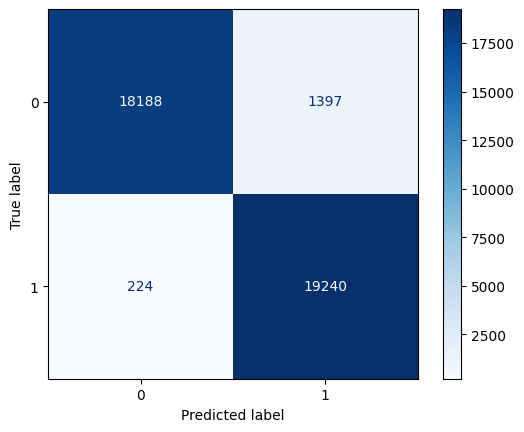

Confusion matrix for the test set:


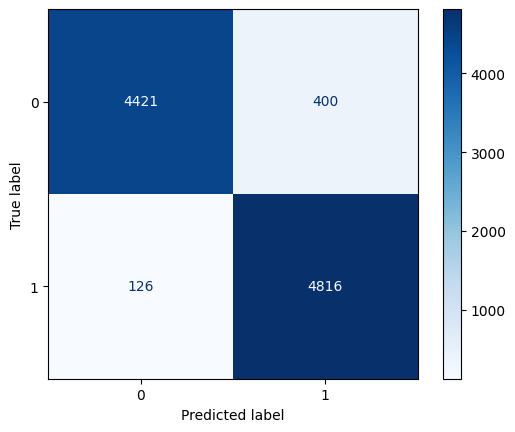

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_lr_1=confusion_matrix(y_train,y_pred_train_1)
con_mat_lr_2=confusion_matrix(y_test,y_pred_test_1)

disp_lr_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_1)
disp_lr_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_lr_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_1)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_1)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_lr_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_lr_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [14]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_1))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_1))

Classification report for the training set:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     19585
           1       0.93      0.99      0.96     19464

    accuracy                           0.96     39049
   macro avg       0.96      0.96      0.96     39049
weighted avg       0.96      0.96      0.96     39049


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      4821
           1       0.92      0.97      0.95      4942

    accuracy                           0.95      9763
   macro avg       0.95      0.95      0.95      9763
weighted avg       0.95      0.95      0.95      9763



<b>b. K-Nearest Neighbours Classification</b>

<i>Model building</i>

In [15]:
from sklearn.neighbors import KNeighborsClassifier

classifier2=KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
classifier2.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<i>Predicting the values for training and test set</i>

In [16]:
y_pred_train_2=classifier2.predict(X_train)
y_pred_test_2=classifier2.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_2.reshape(len(y_pred_train_2),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_2.reshape(len(y_pred_test_2),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[1 1]
 [1 1]
 [1 1]
 ...
 [1 1]
 [0 0]
 [0 1]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [1 1]
 [1 1]
 ...
 [1 1]
 [1 1]
 [1 1]]


<i>Accuracy of the model</i>

Accuracy for the training set: 85.239059%
Accuracy for the test set: 78.479975%

Confusion matrix for the training set:


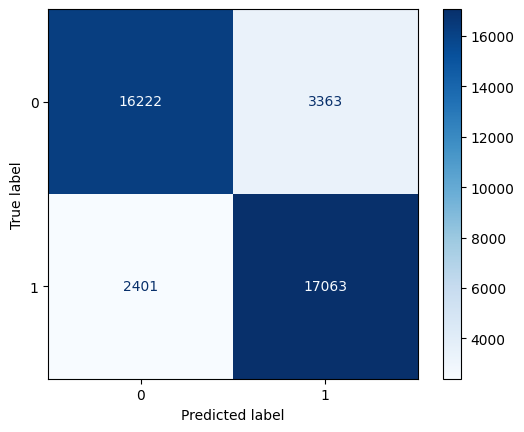

Confusion matrix for the test set:


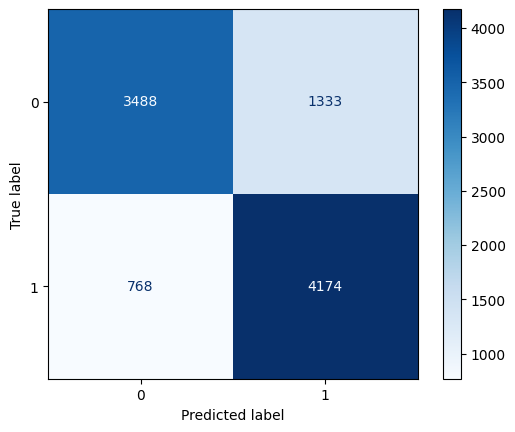

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_knn_1=confusion_matrix(y_train,y_pred_train_2)
con_mat_knn_2=confusion_matrix(y_test,y_pred_test_2)

disp_knn_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_1)
disp_knn_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_knn_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_2)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_2)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_knn_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_knn_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [18]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_2))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_2))

Classification report for the training set:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     19585
           1       0.84      0.88      0.86     19464

    accuracy                           0.85     39049
   macro avg       0.85      0.85      0.85     39049
weighted avg       0.85      0.85      0.85     39049


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      4821
           1       0.76      0.84      0.80      4942

    accuracy                           0.78      9763
   macro avg       0.79      0.78      0.78      9763
weighted avg       0.79      0.78      0.78      9763



<b>c. Naive Baye's Classification</b>

<i>Model building</i>

In [19]:
from sklearn.naive_bayes import GaussianNB

classifier3=GaussianNB()
classifier3.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


<i>Predicting the values for training and test set</i>

In [20]:
y_pred_train_3=classifier3.predict(X_train)
y_pred_test_3=classifier3.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_3.reshape(len(y_pred_train_3),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_3.reshape(len(y_pred_test_3),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[1 1]
 [1 1]
 [1 1]
 ...
 [1 1]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 1]
 [1 1]
 [1 1]
 ...
 [1 1]
 [1 1]
 [1 1]]


<i>Accuracy of the model</i>

Accuracy for the training set: 95.052370%
Accuracy for the test set: 60.268360%

Confusion matrix for the training set:


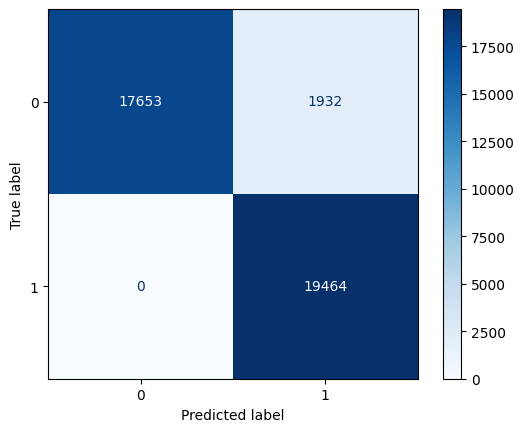

Confusion matrix for the test set:


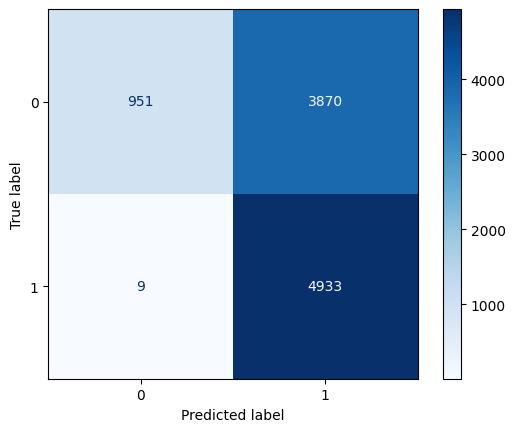

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_nb_1=confusion_matrix(y_train,y_pred_train_3)
con_mat_nb_2=confusion_matrix(y_test,y_pred_test_3)

disp_nb_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_1)
disp_nb_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_nb_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_3)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_3)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_nb_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_nb_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [22]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_3))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_3))

Classification report for the training set:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     19585
           1       0.91      1.00      0.95     19464

    accuracy                           0.95     39049
   macro avg       0.95      0.95      0.95     39049
weighted avg       0.95      0.95      0.95     39049


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.99      0.20      0.33      4821
           1       0.56      1.00      0.72      4942

    accuracy                           0.60      9763
   macro avg       0.78      0.60      0.52      9763
weighted avg       0.77      0.60      0.53      9763



<b>d. Decision Tree Classifier</b>

<i>Model building</i>

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier4=DecisionTreeClassifier(max_depth=5,criterion="gini",random_state=0)
classifier4.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<i>Predicting the values for training and test set</i>

In [24]:
y_pred_train_4=classifier4.predict(X_train)
y_pred_test_4=classifier4.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_4.reshape(len(y_pred_train_4),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_4.reshape(len(y_pred_test_4),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[1 1]
 [1 1]
 [1 1]
 ...
 [1 1]
 [0 0]
 [0 1]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [1 1]
 [1 1]
 ...
 [1 1]
 [1 1]
 [1 1]]


<i>Accuracy of the model</i>

Accuracy for the training set: 82.063561%
Accuracy for the test set: 81.972754%

Confusion matrix for the training set:


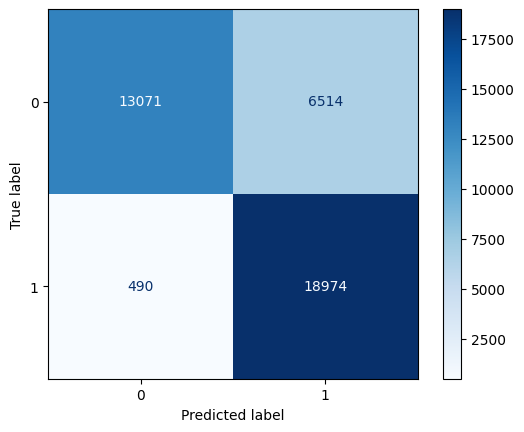

Confusion matrix for the test set:


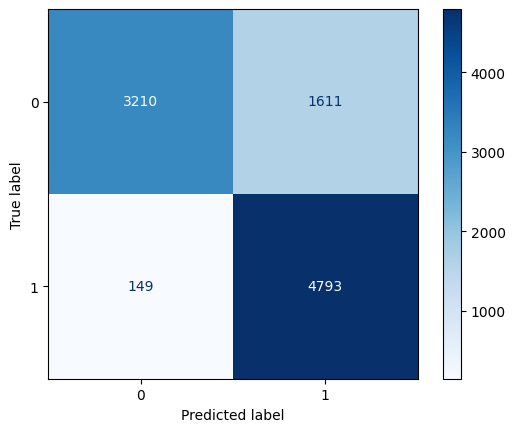

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_dt_1=confusion_matrix(y_train,y_pred_train_4)
con_mat_dt_2=confusion_matrix(y_test,y_pred_test_4)

disp_dt_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_1)
disp_dt_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_dt_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_4)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_4)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_dt_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_dt_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification Report</i>

In [26]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_4))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_4))

Classification report for the training set:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     19585
           1       0.74      0.97      0.84     19464

    accuracy                           0.82     39049
   macro avg       0.85      0.82      0.82     39049
weighted avg       0.85      0.82      0.82     39049


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.96      0.67      0.78      4821
           1       0.75      0.97      0.84      4942

    accuracy                           0.82      9763
   macro avg       0.85      0.82      0.81      9763
weighted avg       0.85      0.82      0.82      9763



<b>e. Random Forest Classifier</b>

<i>Model building</i>

In [32]:
from sklearn.ensemble import RandomForestClassifier

classifier5=RandomForestClassifier(n_estimators=100,random_state=0,criterion="gini",max_depth=5)
classifier5.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<i>Predicting the values for training and test set</i>

In [28]:
y_pred_train_5=classifier5.predict(X_train)
y_pred_test_5=classifier5.predict(X_test)

print("For the training set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train_5.reshape(len(y_pred_train_5),1)),axis=1))
print()

print("For the test set:")
print("[Actual_Observations Predicted_Observations]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test_5.reshape(len(y_pred_test_5),1)),axis=1))

For the training set:
[Actual_Observations Predicted_Observations]
[[1 1]
 [1 0]
 [1 1]
 ...
 [1 1]
 [0 0]
 [0 0]]

For the test set:
[Actual_Observations Predicted_Observations]
[[0 0]
 [1 0]
 [1 0]
 ...
 [1 1]
 [1 0]
 [1 1]]


<i>Accuracy of the model</i>

Accuracy for the training set: 81.139082%
Accuracy for the test set: 80.200758%

Confusion matrix for the training set:


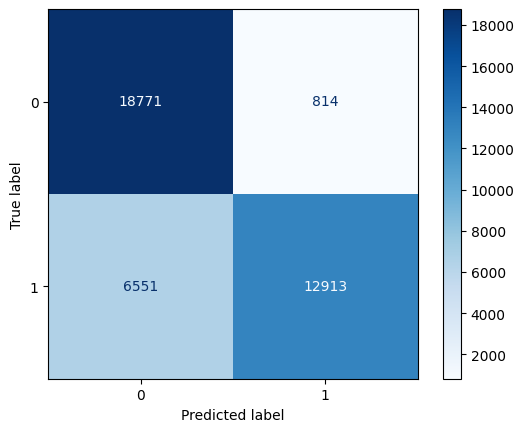

Confusion matrix for the test set:


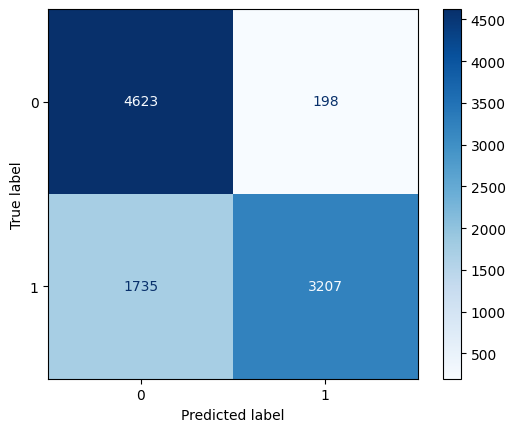

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

con_mat_rf_1=confusion_matrix(y_train,y_pred_train_5)
con_mat_rf_2=confusion_matrix(y_test,y_pred_test_5)

disp_rf_1=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_1)
disp_rf_2=ConfusionMatrixDisplay(confusion_matrix=con_mat_rf_2)

print(f"Accuracy for the training set: {accuracy_score(y_train,y_pred_train_5)*100:2f}%")
print(f"Accuracy for the test set: {accuracy_score(y_test,y_pred_test_5)*100:2f}%")
print()

print("Confusion matrix for the training set:")
disp_rf_1.plot(cmap=plt.cm.Blues)
plt.show()

print("Confusion matrix for the test set:")
disp_rf_2.plot(cmap=plt.cm.Blues)
plt.show()

<i>Classification report</i>

In [30]:
from sklearn.metrics import classification_report

print("Classification report for the training set:")
print(classification_report(y_train,y_pred_train_5))
print()

print("Classification report for the test set:")
print(classification_report(y_test,y_pred_test_5))

Classification report for the training set:
              precision    recall  f1-score   support

           0       0.74      0.96      0.84     19585
           1       0.94      0.66      0.78     19464

    accuracy                           0.81     39049
   macro avg       0.84      0.81      0.81     39049
weighted avg       0.84      0.81      0.81     39049


Classification report for the test set:
              precision    recall  f1-score   support

           0       0.73      0.96      0.83      4821
           1       0.94      0.65      0.77      4942

    accuracy                           0.80      9763
   macro avg       0.83      0.80      0.80      9763
weighted avg       0.84      0.80      0.80      9763



3.<u>Results</u>

| Model | Train Acc | Test Acc | Test Precision (0 / 1) | Test Recall (0 / 1) | Test F1 (0 / 1) |
|---|---|---|---|---|---|
| **Logistic Regression** | 95.85% | **94.61%** | 0.97 / 0.92 | 0.92 / 0.97 | 0.94 / 0.95 |
| KNN (k=5) | 85.24% | 78.48% | 0.82 / 0.76 | 0.72 / 0.84 | 0.77 / 0.80 |
| Gaussian Naive Bayes | 95.05% | 60.27% | 0.99 / 0.56 | 0.20 / 1.00 | 0.33 / 0.72 |
| Decision Tree (depth=5) | 82.06% | 81.97% | 0.96 / 0.75 | 0.67 / 0.97 | 0.78 / 0.84 |
| Random Forest (depth=5, n=100) | 81.14% | 80.20% | 0.96 / 0.73 | 0.67 / 0.96 | 0.79 / 0.83 |

**Best model: Logistic Regression** — 94.6% test accuracy, balanced precision/recall across both classes, minimal train/test gap (95.8% vs 94.6%, no overfitting).

4.<u>Model deployment</u>

In [35]:
import pickle as pk

with open(r"Logistic_Regression.pk","wb") as file:
    pk.dump(classifier1,file)
    
with open(r"CountVectorizer.pk","wb") as file:
    pk.dump(cv,file)